# Soccer Run Clustering

### Goals
- Using the Metrica data (via `kloppy`), cluster 20 different run types that happen during an entire match.
- Apply appropriate normalization, accounting for teams switching sides at halftime.
- Plot the different cluster centers using `mplsoccer`.
- Define "runs" as periods in which an individual player spends above a chosen velocity threshold.


In [ ]:
# Install Some Dependancies for the Lab
!pip install kloppy --quiet
!pip install mplsoccer --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mplsoccer import Pitch
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.special import comb
from kloppy import metrica
import warnings
warnings.filterwarnings('ignore')

In [ ]:
%config InlineBackend.figure_format = 'retina'

Install the constants needed for this lab

In [ ]:
PITCH_LENGTH = 105.0
PITCH_WIDTH = 68.0
FRAME_RATE = 25  # Hz
DT = 1.0 / FRAME_RATE  # 0.04 seconds per frame

PFF FC (blog.fc.pff.com) states that a sprint in soccer is typically any value above 25 km/h (6.94 m/s) for MLS players. Therefore I set a value of 11 m/s as the data often had tracking issues causing unhuman like values.

https://www.blog.fc.pff.com/blog/mls-intensity-xrxc

In [ ]:
# Speed filtering parameters
MAX_REALISTIC_SPEED = 11.0  # m/s (~39.6 km/h) - absolute max for elite players
MAX_JUMP_DISTANCE = 3.0     # meters - to detect tracking errors

# Run extraction parameters
VELOCITY_THRESHOLD = 5.5  # m/s (19.8 km/h) - high-speed running threshold
MIN_DURATION = 0.5        # seconds - minimum run duration

# Clustering parameters
N_CLUSTERS = 20  # number of run types to identify

1) Data Preprocessing, set parameters for maximum speed as tracking system showed 'position jumps' of over 50km/h

In [ ]:
ds = metrica.load_open_data(match_id=1)
df_wide = ds.to_pandas()

# Check for period column
if 'period_id' in df_wide.columns:
    period_col = 'period_id'
elif 'period' in df_wide.columns:
    period_col = 'period'
else:
    raise ValueError("Cannot find period column!")

print(f"  Period column: '{period_col}'")


/tmp/ipython-input-964390719.py:2: DeprecationWarning: Call to deprecated function to_pandas (to_pandas will be removed in the future. Please use to_df instead.).
  df_wide = ds.to_pandas()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Period column: 'period_id'


Define the functions necessary to calculate speed, normalize position for switching at halftime and apply least squares bezier curve so smooth data trajectory. Remove all NaN values from the dataset.

Then extract the "Runs" and run features in order to graph

In [ ]:
def calculate_speed_safe(df, delta_time, max_speed=11.0, max_jump=3.0):
    df = df.copy()

    # Calculate distance and speed
    dx = df['x'].diff()
    dy = df['y'].diff()
    distance = np.sqrt(dx**2 + dy**2)

    # Identify problematic frames
    is_jump = distance > max_jump
    df['speed'] = distance / delta_time

    # Filter outliers
    df.loc[df.index[0], 'speed'] = 0.0  # First frame
    df.loc[is_jump, 'speed'] = np.nan   # Position jumps
    df.loc[df['speed'] > max_speed, 'speed'] = np.nan  # Too fast

    # Interpolate short gaps only
    df['speed'] = df['speed'].interpolate(method='linear', limit=3)
    df['speed'] = df['speed'].fillna(0.0)

    return df


def normalize_positions(x, y, period, pitch_length=105, pitch_width=68):
    x_norm = np.array(x).copy()
    y_norm = np.array(y).copy()

    second_half = np.array(period) == 2
    x_norm[second_half] = pitch_length - x_norm[second_half]
    y_norm[second_half] = pitch_width - y_norm[second_half]

    return x_norm, y_norm


def get_bezier_parameters(X, Y, degree=2):
    X, Y = np.asarray(X), np.asarray(Y)
    T = np.linspace(0, 1, len(X))
    M = np.stack([
        comb(degree, i) * (T ** i) * ((1 - T) ** (degree - i))
        for i in range(degree + 1)
    ], axis=1)
    return (np.linalg.pinv(M) @ np.stack([X, Y], axis=1)).tolist()


def apply_bezier_curve(x, y, num_points=100):
    if len(x) < 3:
        return x, y

    # Remove NaN
    valid = ~(np.isnan(x) | np.isnan(y))
    x_valid = np.array(x)[valid]
    y_valid = np.array(y)[valid]

    if len(x_valid) < 3:
        return x_valid, y_valid

    try:
        # Get Bezier control points
        control_points = get_bezier_parameters(x_valid, y_valid, degree=2)

        # Generate smooth curve
        t = np.linspace(0, 1, num_points)

        bezier_x = (
            (1 - t)**2 * control_points[0][0] +
            2 * (1 - t) * t * control_points[1][0] +
            t**2 * control_points[2][0]
        )

        bezier_y = (
            (1 - t)**2 * control_points[0][1] +
            2 * (1 - t) * t * control_points[1][1] +
            t**2 * control_points[2][1]
        )

        return bezier_x, bezier_y
    except:
        return x_valid, y_valid


Define all runs using tracking data, including their velocity, duration, direction and path (including curvature)

In [ ]:
def extract_runs(tracking_data, velocity_threshold, min_duration, delta_time):
    runs = []

    for (team, player_id), player_data in tracking_data.groupby(['team', 'player_id']):
        player_data = player_data.sort_values('frame').reset_index(drop=True)

        # Find periods above threshold
        above_threshold = player_data['speed'].values >= velocity_threshold

        # Find transitions
        transitions = np.diff(above_threshold.astype(int))
        run_starts = np.where(transitions == 1)[0] + 1
        run_ends = np.where(transitions == -1)[0] + 1

        # Handle edge cases
        if above_threshold[0]:
            run_starts = np.insert(run_starts, 0, 0)
        if above_threshold[-1]:
            run_ends = np.append(run_ends, len(player_data))

        # Extract each run
        for start_idx, end_idx in zip(run_starts, run_ends):
            if end_idx <= start_idx:
                continue

            run_segment = player_data.iloc[start_idx:end_idx]
            duration = len(run_segment) * delta_time

            if duration >= min_duration and len(run_segment) >= 3:
                period = run_segment['period'].iloc[0]

                # Calculate distance
                distances = np.sqrt(
                    np.diff(run_segment['x'])**2 +
                    np.diff(run_segment['y'])**2
                )
                total_distance = np.sum(distances)

                runs.append({
                    'team': team,
                    'player_id': player_id,
                    'x': run_segment['x'].values,
                    'y': run_segment['y'].values,
                    'frame': run_segment['frame'].values,
                    'period': period,
                    'speed': run_segment['speed'].values,
                    'duration': duration,
                    'max_speed': run_segment['speed'].max(),
                    'avg_speed': run_segment['speed'].mean(),
                    'distance': total_distance
                })

    return runs


def create_run_features(runs, pitch_length=105, pitch_width=68):
    features = []

    for run in runs:
        # Normalize for halftime
        period_array = np.full(len(run['x']), run['period'])
        x_norm, y_norm = normalize_positions(
            run['x'], run['y'], period_array,
            pitch_length, pitch_width
        )

        # Basic features
        start_x, start_y = x_norm[0], y_norm[0]
        end_x, end_y = x_norm[-1], y_norm[-1]

        direction = np.arctan2(end_y - start_y, end_x - start_x)
        distance = run['distance']
        duration = run['duration']
        avg_speed = run['avg_speed']
        max_speed = run['max_speed']

        # Curvature (sum of direction changes)
        if len(x_norm) >= 3:
            angles = []
            for i in range(1, len(x_norm)-1):
                v1 = np.array([x_norm[i] - x_norm[i-1], y_norm[i] - y_norm[i-1]])
                v2 = np.array([x_norm[i+1] - x_norm[i], y_norm[i+1] - y_norm[i]])

                norm1, norm2 = np.linalg.norm(v1), np.linalg.norm(v2)
                if norm1 > 0 and norm2 > 0:
                    angle = np.arccos(np.clip(np.dot(v1, v2) / (norm1 * norm2), -1, 1))
                    angles.append(angle)

            curvature = np.sum(angles) if angles else 0
        else:
            curvature = 0

        # Create normalized feature vector
        feature_vec = [
            start_x / pitch_length,    # [0, 1]
            start_y / pitch_width,      # [0, 1]
            end_x / pitch_length,       # [0, 1]
            end_y / pitch_width,        # [0, 1]
            direction / np.pi,          # [-1, 1]
            distance / pitch_length,    # typically [0, 1]
            duration / 10.0,            # typical max ~10s
            avg_speed / 10.0,           # typical max ~10 m/s
            max_speed / 10.0,           # typical max ~10 m/s
            curvature / np.pi           # normalized angle sum
        ]

        features.append(feature_vec)

    return np.array(features)

Extract Relevant player data for the Home and away teams, filter out players who had less than 100 frames of data tracking to filter incomplete data and allow for meaningful analysis

In [ ]:
all_players = []

# Home team
print("\nProcessing home team...")
for i in range(1, 12):
    x_col = f'home_{i}_x'
    y_col = f'home_{i}_y'

    if x_col in df_wide.columns and y_col in df_wide.columns:
        player_df = pd.DataFrame({
            'frame': range(len(df_wide)),
            'period': df_wide[period_col].values,
            'x': df_wide[x_col].values * PITCH_LENGTH,  # Scale to meters
            'y': df_wide[y_col].values * PITCH_WIDTH,   # Scale to meters
            'team': 'home',
            'player_id': f'home_{i}'
        })

        player_df = player_df.dropna(subset=['x', 'y'])

        if len(player_df) > 100:
            player_df = player_df.sort_values('frame').reset_index(drop=True)
            player_df = calculate_speed_safe(player_df, DT, MAX_REALISTIC_SPEED, MAX_JUMP_DISTANCE)
            all_players.append(player_df)
            print(f"  ✓ home_{i}: {len(player_df):,} frames, max speed: {player_df['speed'].max():.2f} m/s")

# Away team
print("\nProcessing away team...")
for i in range(1, 12):
    x_col = f'away_{i}_x'
    y_col = f'away_{i}_y'

    if x_col in df_wide.columns and y_col in df_wide.columns:
        player_df = pd.DataFrame({
            'frame': range(len(df_wide)),
            'period': df_wide[period_col].values,
            'x': df_wide[x_col].values * PITCH_LENGTH,  # Scale to meters
            'y': df_wide[y_col].values * PITCH_WIDTH,   # Scale to meters
            'team': 'away',
            'player_id': f'away_{i}'
        })

        player_df = player_df.dropna(subset=['x', 'y'])

        if len(player_df) > 100:
            player_df = player_df.sort_values('frame').reset_index(drop=True)
            player_df = calculate_speed_safe(player_df, DT, MAX_REALISTIC_SPEED, MAX_JUMP_DISTANCE)
            all_players.append(player_df)
            print(f"  ✓ away_{i}: {len(player_df):,} frames, max speed: {player_df['speed'].max():.2f} m/s")

tracking_data = pd.concat(all_players, ignore_index=True)

print(f"\n✓ Total players processed: {len(all_players)}")
print(f"✓ Total tracking frames: {len(tracking_data):,}")
print(f"✓ Overall max speed: {tracking_data['speed'].max():.2f} m/s ({tracking_data['speed'].max()*3.6:.1f} km/h)")
print(f"✓ Speed 95th percentile: {np.percentile(tracking_data['speed'], 95):.2f} m/s ({np.percentile(tracking_data['speed'], 95)*3.6:.1f} km/h)")



Processing home team...
  ✓ home_1: 46,706 frames, max speed: 8.46 m/s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  ✓ home_2: 145,006 frames, max speed: 10.97 m/s
  ✓ home_3: 145,006 frames, max speed: 10.95 m/s
  ✓ home_4: 145,006 frames, max speed: 9.71 m/s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  ✓ home_5: 145,006 frames, max speed: 9.96 m/s
  ✓ home_6: 110,849 frames, max speed: 8.01 m/s


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  ✓ home_9: 145,006 frames, max speed: 10.94 m/s
  ✓ home_10: 121,392 frames, max speed: 10.90 m/s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  ✓ home_11: 145,006 frames, max speed: 9.47 m/s

Processing away team...

✓ Total players processed: 11
✓ Total tracking frames: 1,438,995
✓ Overall max speed: 10.97 m/s (39.5 km/h)
✓ Speed 95th percentile: 4.41 m/s (15.9 km/h)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This shows that 1,438,995 frames were processed from this dataset, with an overall max speed value of 10.97 m/s. Therefore once the data was processed to remove any NaN, as well as jumps in tracking the data seems to follow my estimate to set the extreme at 11 m/s.

Extract the runs from the dataset using the tracking data, velocity threshold (11 m/s), min duration, and difference in time

In [ ]:
runs = extract_runs(tracking_data, VELOCITY_THRESHOLD, MIN_DURATION, DT)

print(f"✓ Extracted {len(runs)} high-speed runs")

if len(runs) > 0:
    durations = [r['duration'] for r in runs]
    distances = [r['distance'] for r in runs]
    max_speeds = [r['max_speed'] for r in runs]
    avg_speeds = [r['avg_speed'] for r in runs]

    print(f"\nRun Statistics:")
    print(f"  Duration:   {np.mean(durations):5.2f} ± {np.std(durations):4.2f} seconds")
    print(f"  Distance:   {np.mean(distances):5.2f} ± {np.std(distances):4.2f} meters")
    print(f"  Max speed:  {np.mean(max_speeds):5.2f} ± {np.std(max_speeds):4.2f} m/s")
    print(f"  Avg speed:  {np.mean(avg_speeds):5.2f} ± {np.std(avg_speeds):4.2f} m/s")
else:
    print("\n⚠️ WARNING: No runs found! Try lowering the velocity threshold.")
    print("Stopping here - cannot proceed without runs.")
    raise ValueError("No runs extracted")

✓ Extracted 410 high-speed runs

Run Statistics:
  Duration:    2.58 ± 1.91 seconds
  Distance:   16.50 ± 13.64 meters
  Max speed:   6.74 ± 0.95 m/s
  Avg speed:   6.22 ± 0.55 m/s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Objective 1: Create 20 Different Run Clusters

Create Features for the run clusters, include normalized start and end position + direction. As well, use distance covered and duration for sprint speed.

In [ ]:
features = create_run_features(runs, PITCH_LENGTH, PITCH_WIDTH)

# Standardize and cluster
print(f"\nApplying K-Means clustering (k={N_CLUSTERS})...")

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(features_scaled)
labels = kmeans.labels_

# Cluster distribution
unique, counts = np.unique(labels, return_counts=True)
print(f"\n✓ Created {N_CLUSTERS} clusters")
print("\nCluster Distribution:")
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id:2d}: {count:4d} runs ({count/len(runs)*100:5.1f}%)")


Applying K-Means clustering (k=20)...

✓ Created 20 clusters

Cluster Distribution:
  Cluster  0:   37 runs (  9.0%)
  Cluster  1:   26 runs (  6.3%)
  Cluster  2:   25 runs (  6.1%)
  Cluster  3:   21 runs (  5.1%)
  Cluster  4:   34 runs (  8.3%)
  Cluster  5:    8 runs (  2.0%)
  Cluster  6:   33 runs (  8.0%)
  Cluster  7:   18 runs (  4.4%)
  Cluster  8:   27 runs (  6.6%)
  Cluster  9:   26 runs (  6.3%)
  Cluster 10:    2 runs (  0.5%)
  Cluster 11:   26 runs (  6.3%)
  Cluster 12:   25 runs (  6.1%)
  Cluster 13:    7 runs (  1.7%)
  Cluster 14:   20 runs (  4.9%)
  Cluster 15:    4 runs (  1.0%)
  Cluster 16:   32 runs (  7.8%)
  Cluster 17:   10 runs (  2.4%)
  Cluster 18:   18 runs (  4.4%)
  Cluster 19:   11 runs (  2.7%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Create a plot of the 20 clusters, have to define clusters by solving for the mean and standard deviation for each.

Utilize cluster centres for plot

In [ ]:
# Colors for 20 clusters
colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
    '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000',
    '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080'
]

def calculate_cluster_stats(runs, labels, n_clusters, pitch_length=105, pitch_width=68):
    """Calculate mean and std for each cluster."""
    cluster_stats = {}

    for cluster_id in range(n_clusters):
        cluster_runs = [runs[i] for i in range(len(runs)) if labels[i] == cluster_id]

        if len(cluster_runs) == 0:
            continue

        all_start_x, all_start_y = [], []
        all_end_x, all_end_y = [], []

        for run in cluster_runs:
            period_array = np.full(len(run['x']), run['period'])
            x_norm, y_norm = normalize_positions(
                run['x'], run['y'], period_array,
                pitch_length, pitch_width
            )
            all_start_x.append(x_norm[0])
            all_start_y.append(y_norm[0])
            all_end_x.append(x_norm[-1])
            all_end_y.append(y_norm[-1])

        cluster_stats[cluster_id] = {
            'start_mean': (np.mean(all_start_x), np.mean(all_start_y)),
            'start_std': (np.std(all_start_x), np.std(all_start_y)),
            'end_mean': (np.mean(all_end_x), np.mean(all_end_y)),
            'end_std': (np.std(all_end_x), np.std(all_end_y)),
            'count': len(cluster_runs)
        }

    return cluster_stats

cluster_stats = calculate_cluster_stats(runs, labels, N_CLUSTERS, PITCH_LENGTH, PITCH_WIDTH)

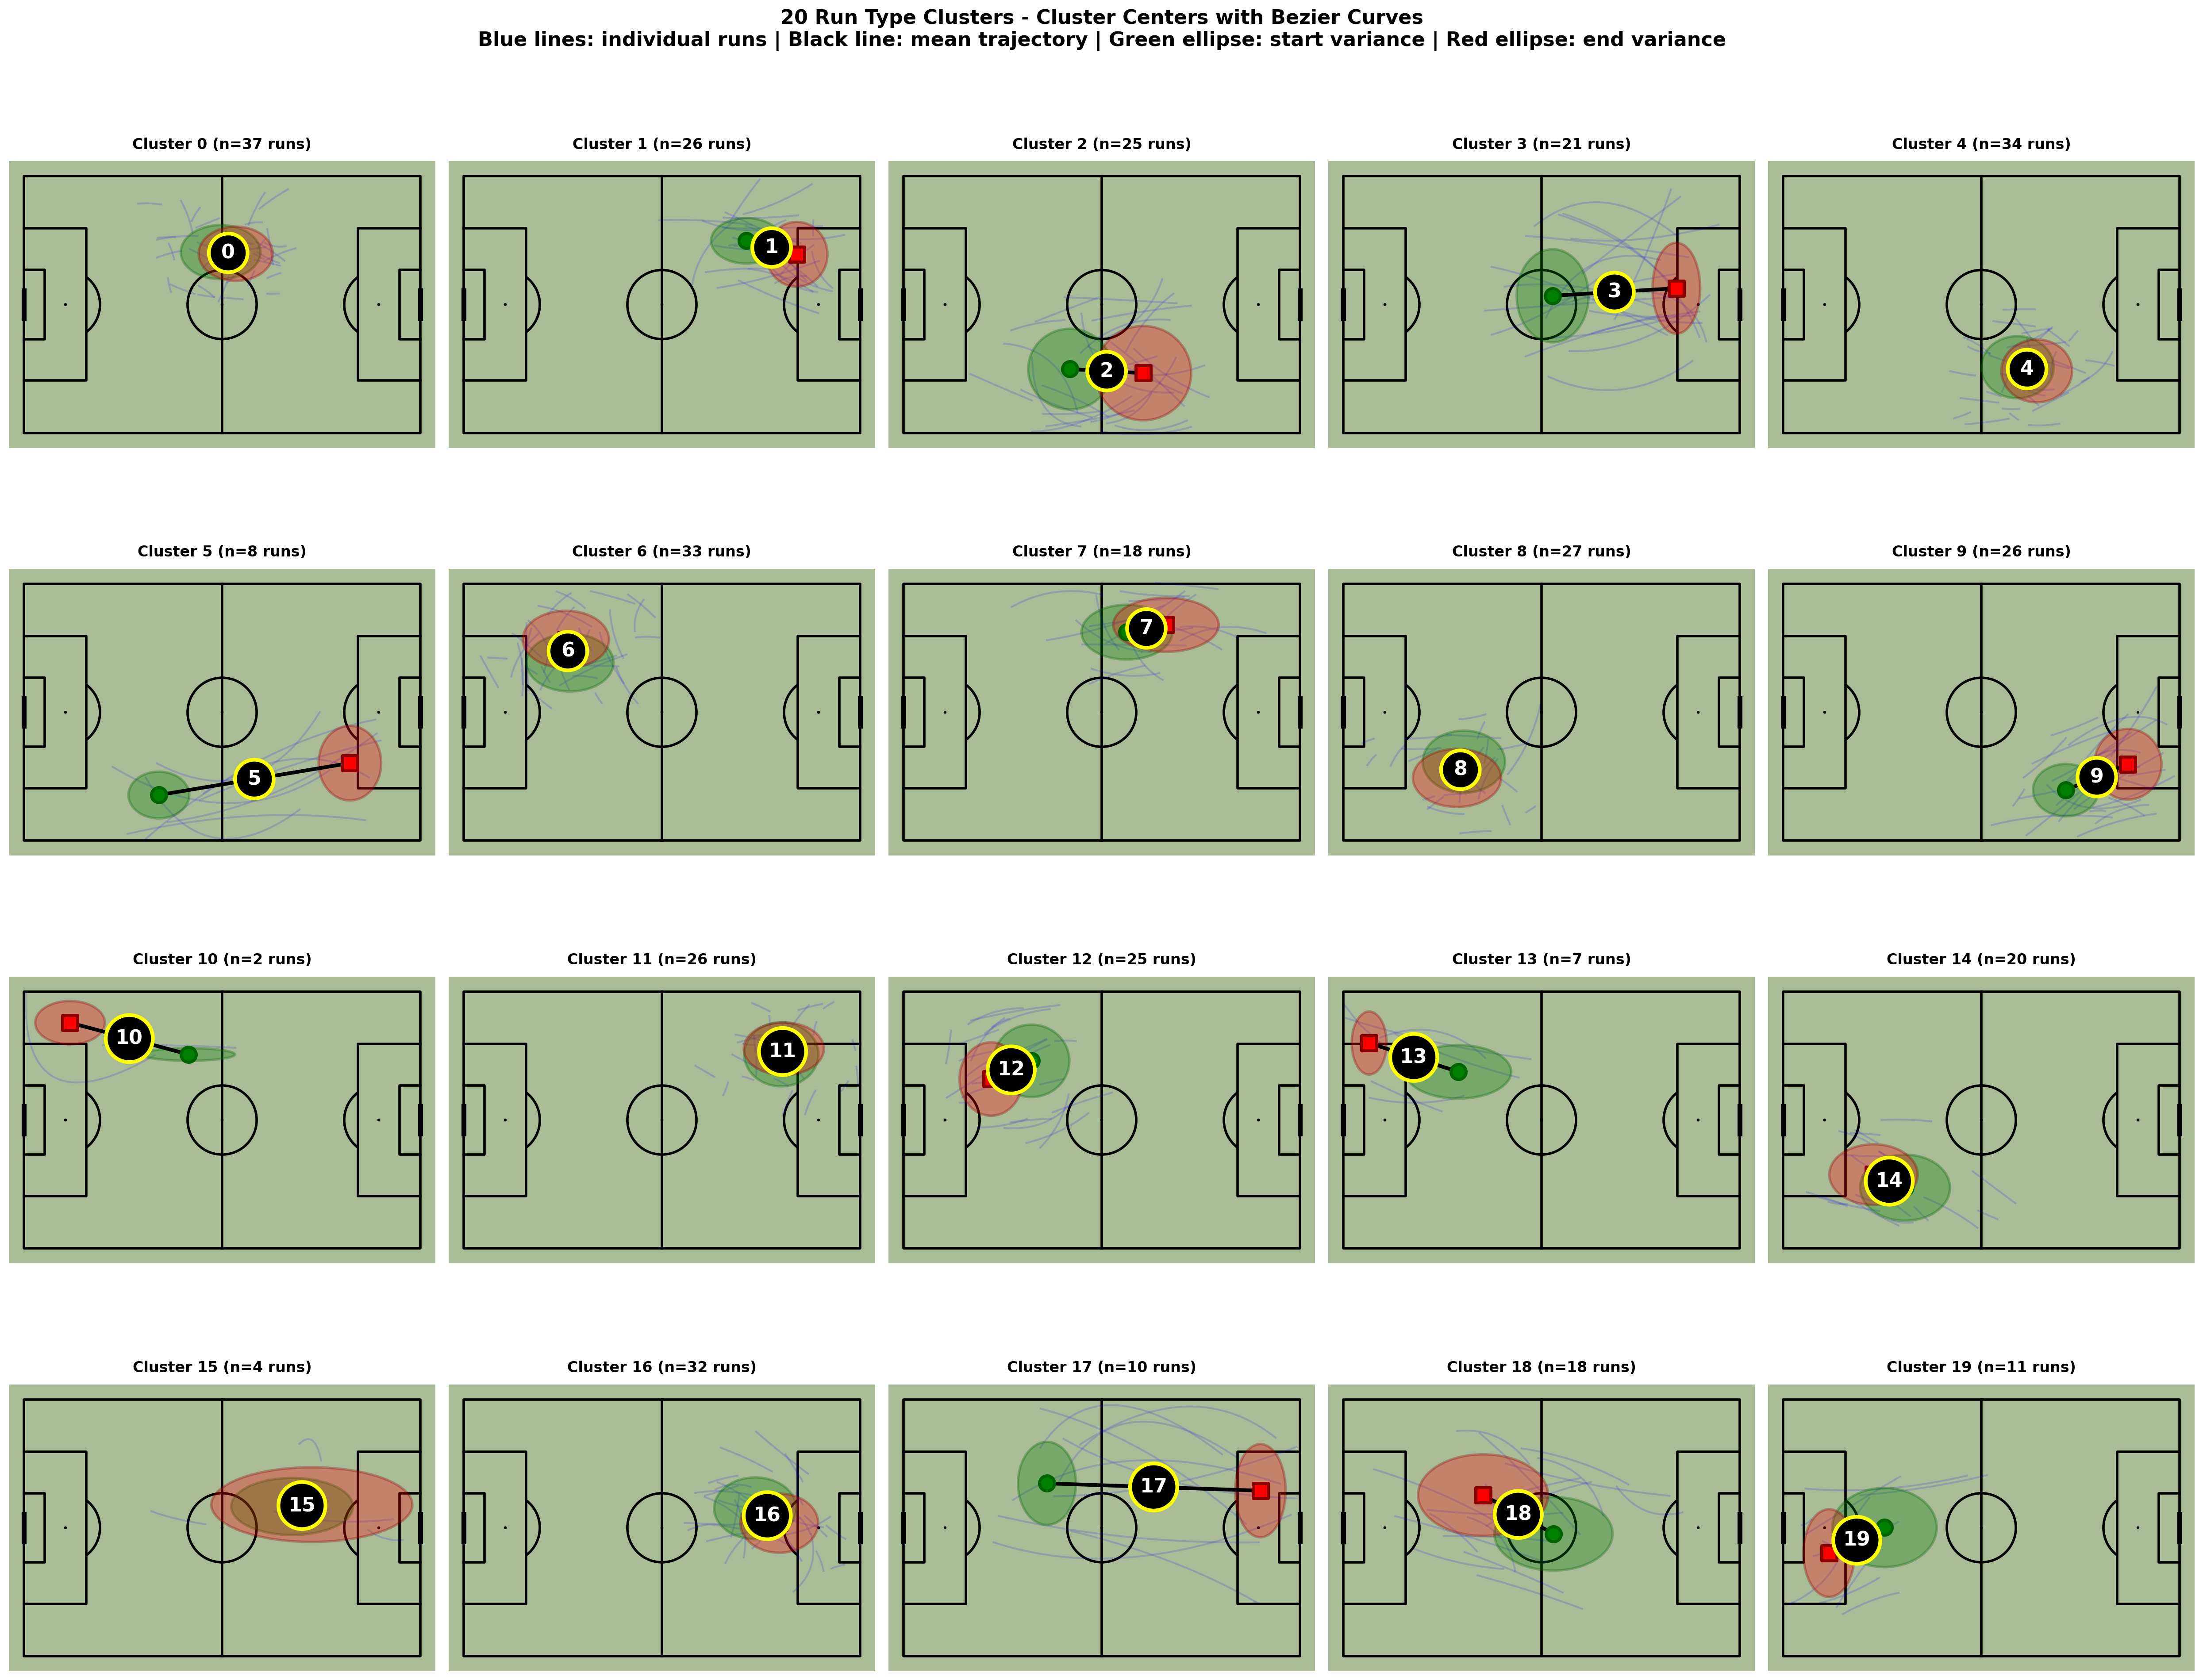

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(25, 20))
axes = axes.flatten()

for cluster_id in range(N_CLUSTERS):
    ax = axes[cluster_id]

    pitch = Pitch(pitch_type='custom', pitch_length=PITCH_LENGTH,
                 pitch_width=PITCH_WIDTH, line_color='black',
                 pitch_color='#aabb97', linewidth=2)
    pitch.draw(ax=ax)

    cluster_runs = [runs[i] for i in range(len(runs)) if labels[i] == cluster_id]

    # Plot individual runs with Bezier smoothing
    for run in cluster_runs:
        period_array = np.full(len(run['x']), run['period'])
        x_norm, y_norm = normalize_positions(
            run['x'], run['y'], period_array,
            PITCH_LENGTH, PITCH_WIDTH
        )

        bezier_x, bezier_y = apply_bezier_curve(x_norm, y_norm, num_points=100)

        pitch.plot(bezier_x, bezier_y, ax=ax, color='blue',
                  alpha=0.15, lw=1.5, zorder=1)

    # Plot cluster center
    if cluster_id in cluster_stats:
        stats = cluster_stats[cluster_id]

        # Start position ellipse (green)
        ellipse_start = Ellipse(
            xy=stats['start_mean'],
            width=2 * stats['start_std'][0],
            height=2 * stats['start_std'][1],
            facecolor='green', alpha=0.3,
            edgecolor='darkgreen', linewidth=2, zorder=2
        )
        ax.add_patch(ellipse_start)

        # End position ellipse (red)
        ellipse_end = Ellipse(
            xy=stats['end_mean'],
            width=2 * stats['end_std'][0],
            height=2 * stats['end_std'][1],
            facecolor='red', alpha=0.3,
            edgecolor='darkred', linewidth=2, zorder=2
        )
        ax.add_patch(ellipse_end)

        # Mean trajectory
        pitch.plot(
            [stats['start_mean'][0], stats['end_mean'][0]],
            [stats['start_mean'][1], stats['end_mean'][1]],
            ax=ax, color='black', lw=3, zorder=3
        )

        # Cluster number
        mid_x = (stats['start_mean'][0] + stats['end_mean'][0]) / 2
        mid_y = (stats['start_mean'][1] + stats['end_mean'][1]) / 2

        ax.text(mid_x, mid_y, str(cluster_id),
               fontsize=16, fontweight='bold', color='white',
               ha='center', va='center',
               bbox=dict(boxstyle='circle,pad=0.5',
                        facecolor='black',
                        edgecolor='yellow',
                        linewidth=3),
               zorder=5)

        # Start marker (green circle)
        pitch.scatter(stats['start_mean'][0], stats['start_mean'][1],
                     ax=ax, color='green', s=150, zorder=4,
                     edgecolors='darkgreen', linewidth=2.5)

        # End marker (red square)
        pitch.scatter(stats['end_mean'][0], stats['end_mean'][1],
                     ax=ax, color='red', s=150, zorder=4, marker='s',
                     edgecolors='darkred', linewidth=2.5)

        ax.set_title(f'Cluster {cluster_id} (n={stats["count"]} runs)',
                    fontsize=12, fontweight='bold', pad=10)
    else:
        ax.set_title(f'Cluster {cluster_id} (n=0 runs)', fontsize=12)

plt.suptitle('20 Run Type Clusters - Cluster Centers with Bezier Curves\n' +
             'Blue lines: individual runs | Black line: mean trajectory | ' +
             'Green ellipse: start variance | Red ellipse: end variance',
             fontsize=16, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig('run_cluster_centers_FINAL.png', dpi=300, bbox_inches='tight')
plt.show()

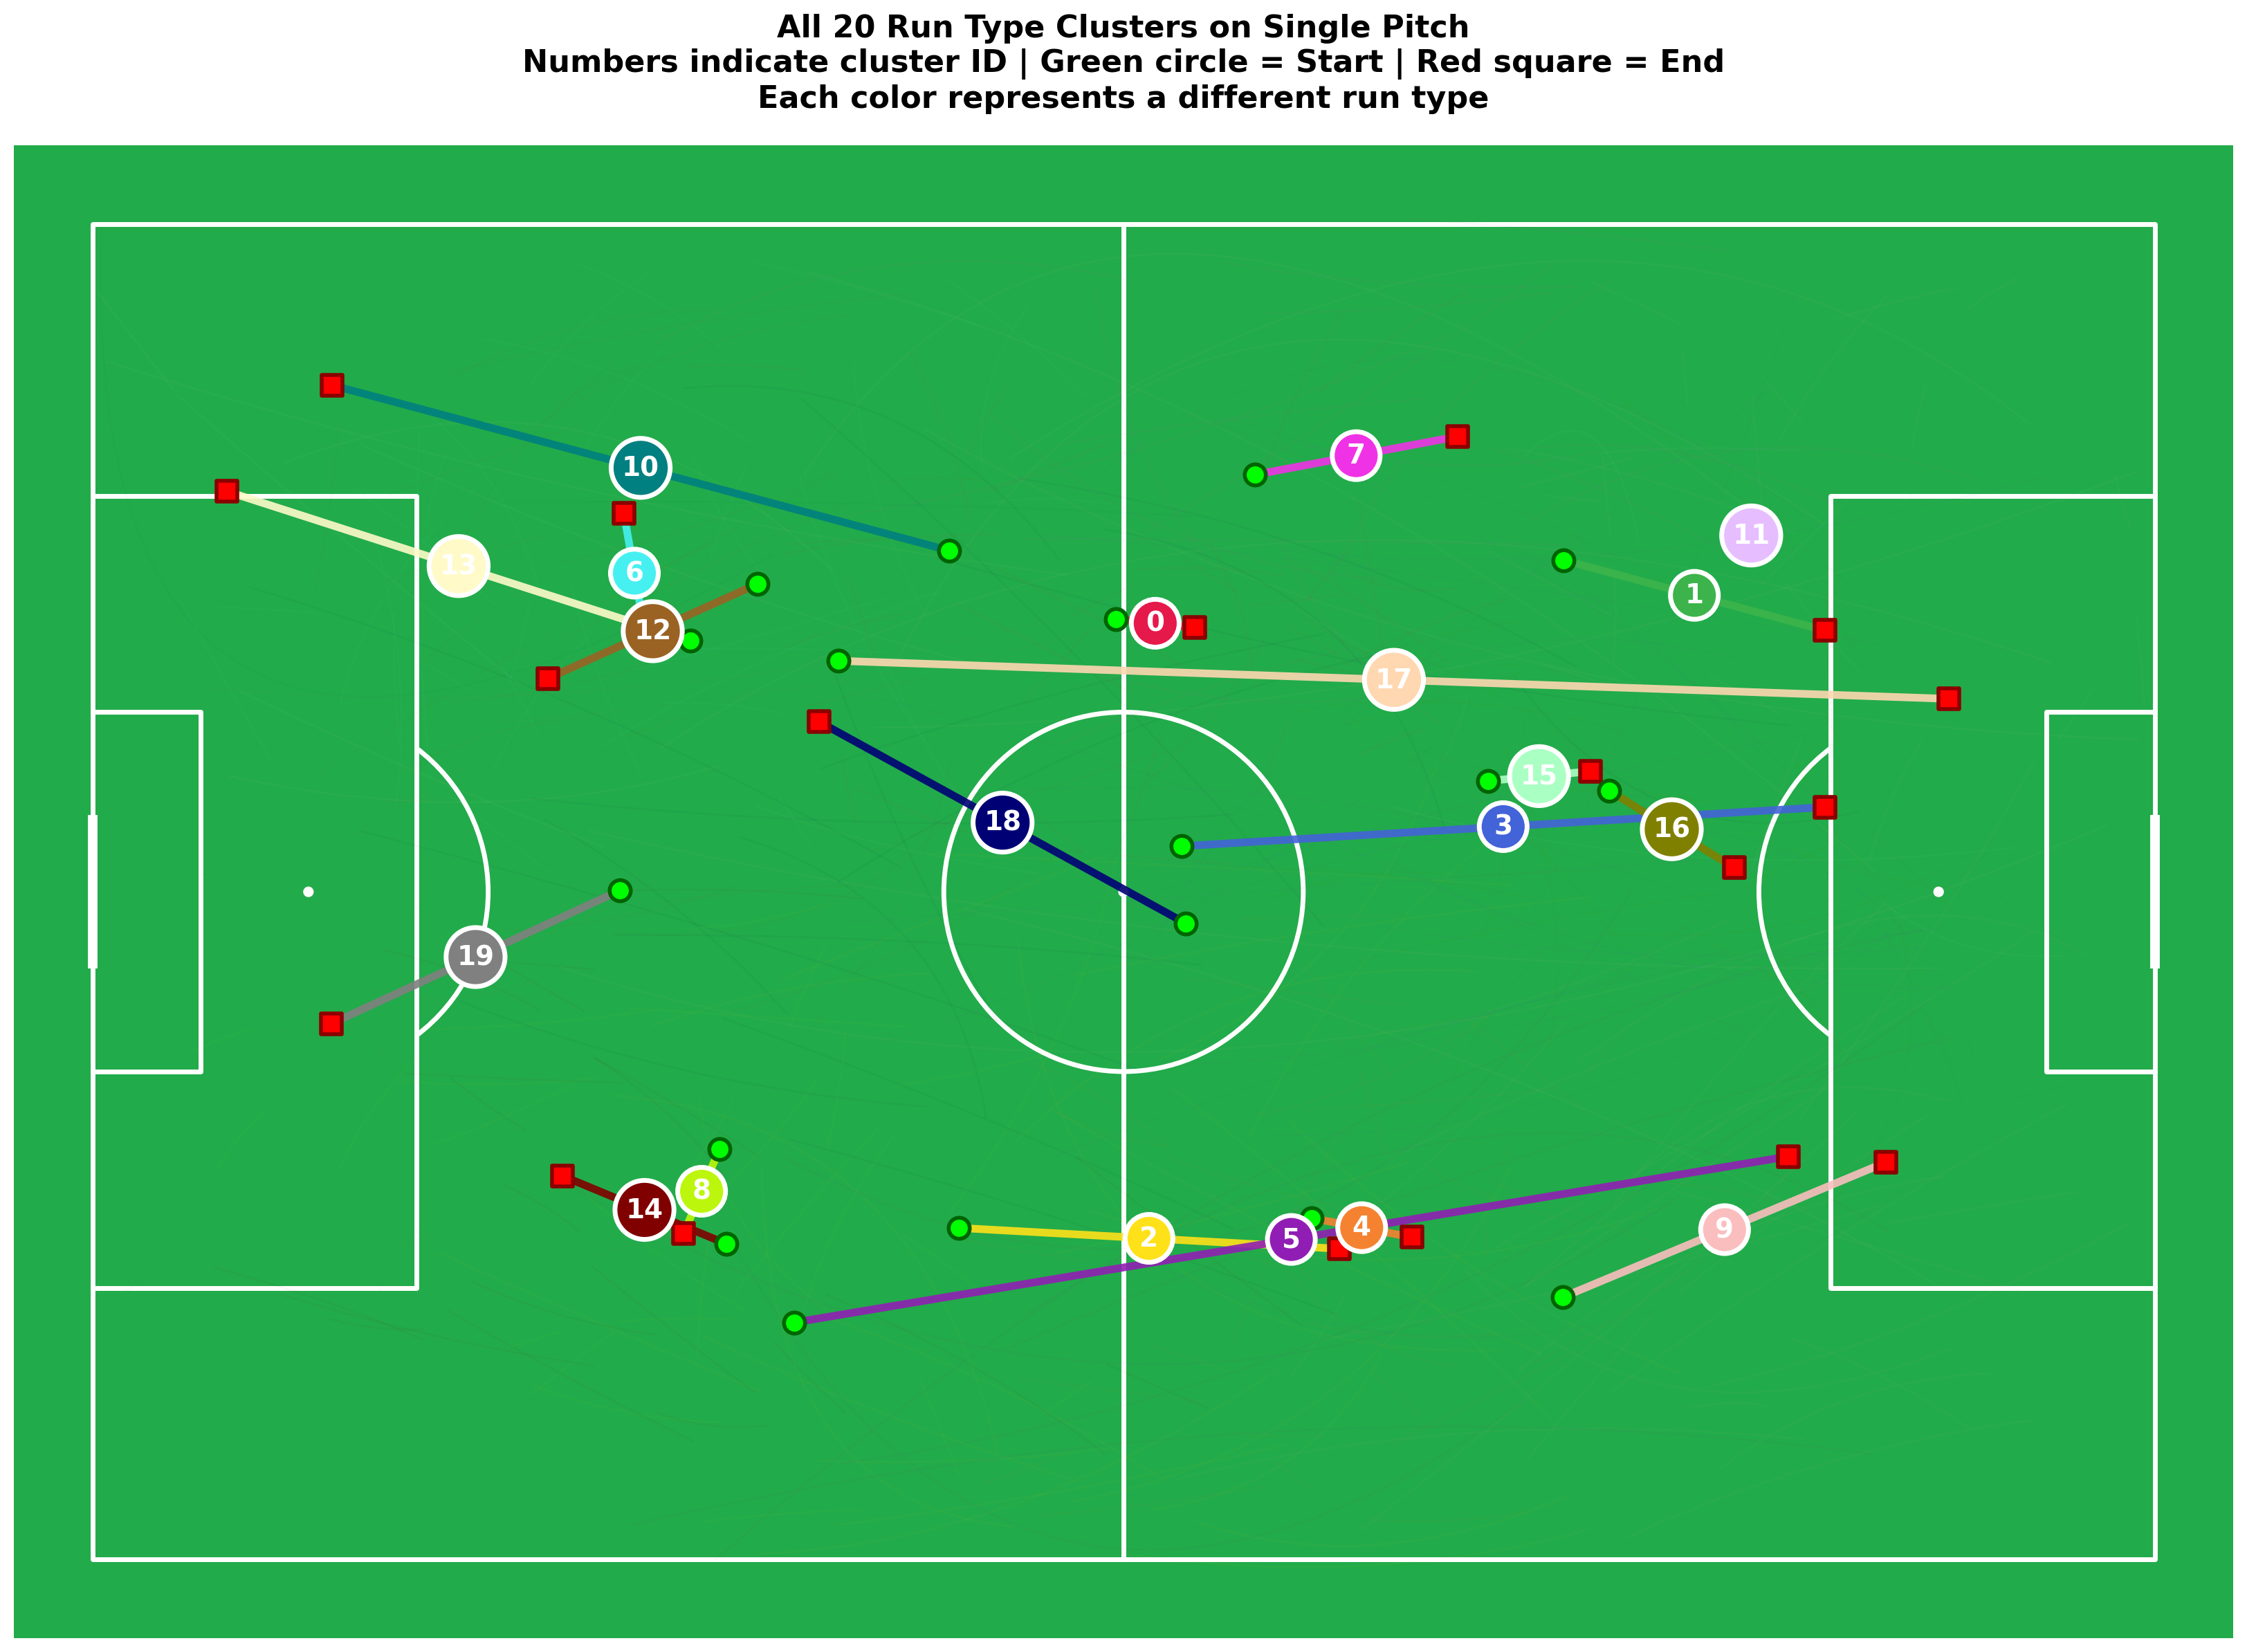

In [ ]:
fig, ax = plt.subplots(figsize=(18, 12))

pitch = Pitch(pitch_type='custom', pitch_length=PITCH_LENGTH,
             pitch_width=PITCH_WIDTH, line_color='white',
             pitch_color='#22ab4a', linewidth=2.5)
pitch.draw(ax=ax)

for cluster_id in range(N_CLUSTERS):
    cluster_runs = [runs[i] for i in range(len(runs)) if labels[i] == cluster_id]

    if len(cluster_runs) == 0:
        continue

    color = colors[cluster_id]

    # Plot individual runs (very transparent)
    for run in cluster_runs:
        period_array = np.full(len(run['x']), run['period'])
        x_norm, y_norm = normalize_positions(
            run['x'], run['y'], period_array,
            PITCH_LENGTH, PITCH_WIDTH
        )

        bezier_x, bezier_y = apply_bezier_curve(x_norm, y_norm, num_points=100)

        pitch.plot(bezier_x, bezier_y, ax=ax, color=color,
                  alpha=0.03, lw=1, zorder=1)

    # Plot mean trajectory
    if cluster_id in cluster_stats:
        stats = cluster_stats[cluster_id]

        pitch.plot(
            [stats['start_mean'][0], stats['end_mean'][0]],
            [stats['start_mean'][1], stats['end_mean'][1]],
            ax=ax, color=color, lw=4, alpha=0.9, zorder=3
        )

        # Cluster number
        mid_x = (stats['start_mean'][0] + stats['end_mean'][0]) / 2
        mid_y = (stats['start_mean'][1] + stats['end_mean'][1]) / 2

        ax.text(mid_x, mid_y, str(cluster_id),
               fontsize=14, fontweight='bold', color='white',
               ha='center', va='center',
               bbox=dict(boxstyle='circle,pad=0.4',
                        facecolor=color,
                        edgecolor='white',
                        linewidth=2.5),
               zorder=5)

        # Start marker
        pitch.scatter(stats['start_mean'][0], stats['start_mean'][1],
                     ax=ax, color='lime', s=120, zorder=4,
                     edgecolors='darkgreen', linewidth=2)

        # End marker
        pitch.scatter(stats['end_mean'][0], stats['end_mean'][1],
                     ax=ax, color='red', s=120, zorder=4, marker='s',
                     edgecolors='darkred', linewidth=2)

ax.set_title('All 20 Run Type Clusters on Single Pitch\n' +
            'Numbers indicate cluster ID | Green circle = Start | Red square = End\n' +
            'Each color represents a different run type',
            fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('all_clusters_single_pitch_FINAL.png', dpi=300, bbox_inches='tight')
plt.show()

This plot consists of the 20 run clusters on the same pitch. The green circle is the start position, the red square is the stop position

In [ ]:
print("\n" + "="*80)
print("CLUSTER CHARACTERISTICS SUMMARY")
print("="*80)

print(f"\n{'Cluster':<10} {'Count':<8} {'Duration':<12} {'Distance':<12} {'Max Speed':<15} {'Direction'}")
print("="*100)

for cluster_id in range(N_CLUSTERS):
    cluster_runs = [runs[i] for i in range(len(runs)) if labels[i] == cluster_id]

    if len(cluster_runs) == 0:
        continue

    avg_duration = np.mean([r['duration'] for r in cluster_runs])
    avg_distance = np.mean([r['distance'] for r in cluster_runs])
    avg_max_speed = np.mean([r['max_speed'] for r in cluster_runs])

    # Direction
    if cluster_id in cluster_stats:
        stats = cluster_stats[cluster_id]
        dx = stats['end_mean'][0] - stats['start_mean'][0]
        dy = stats['end_mean'][1] - stats['start_mean'][1]

        if abs(dx) > abs(dy):
            direction = "Forward →" if dx > 0 else "Backward ←"
        else:
            direction = "Right ↗" if dy > 0 else "Left ↙"
    else:
        direction = "N/A"

    print(f"{cluster_id:<10} {len(cluster_runs):<8} "
          f"{avg_duration:>5.2f}s      "
          f"{avg_distance:>5.2f}m      "
          f"{avg_max_speed:>5.2f} m/s      "
          f"{direction}")

print("="*100)


CLUSTER CHARACTERISTICS SUMMARY

Cluster    Count    Duration     Distance     Max Speed       Direction
0          37        1.12s       6.25m       5.90 m/s      Forward →
1          26        2.64s      17.60m       7.65 m/s      Forward →
2          25        3.61s      22.58m       6.91 m/s      Forward →
3          21        5.34s      37.19m       8.05 m/s      Forward →
4          34        1.34s       7.67m       6.07 m/s      Forward →
5          8         8.17s      55.66m       7.75 m/s      Forward →
6          33        1.58s       9.27m       6.28 m/s      Right ↗
7          18        3.10s      19.03m       6.67 m/s      Forward →
8          27        1.41s       7.98m       5.99 m/s      Left ↙
9          26        2.94s      19.44m       7.59 m/s      Forward →
10         2         6.34s      42.05m       7.64 m/s      Backward ←
11         26        0.98s       5.47m       6.02 m/s      Right ↗
12         25        2.08s      12.29m       6.23 m/s      Backward ←
13

**Discussion:**

Looking at the results of this lab and the trends from the clusters, max speed values topped out at 10.97 m/s (~40 km/h). Adjusting for the variance and based on the data from PFF discussed earlier, the values above 6.94 m/s typically suggest a players sprint but for the sake of a large data sample, lower this to 5.5 m/s can help evaluation.

From analysis of the clusters, Cluster 1 was the most frequeny with a count of 37 and the max speed of 5.90 m/s. The fastest cluster was Cluster 15, with a speed of 9.39 m/s but an occurence of only four times within the data. The general trend shows a lower occurence of high max speed which makes sense as in soccer there are less moments of full sprint as most of the game relies on moderate pace with passing or ball handling.

**Extra**: wanted to see what adding a confidence region plot would look like for the clusters

added clusters for start and end of position to look at effective range they influence during the change in position.

The graphs may need some tuning but it shows an interesting depiction of the essence of space in soccer. More importantly, it shows the effective range that players create when they move around which is crucial for game theory and strategy.

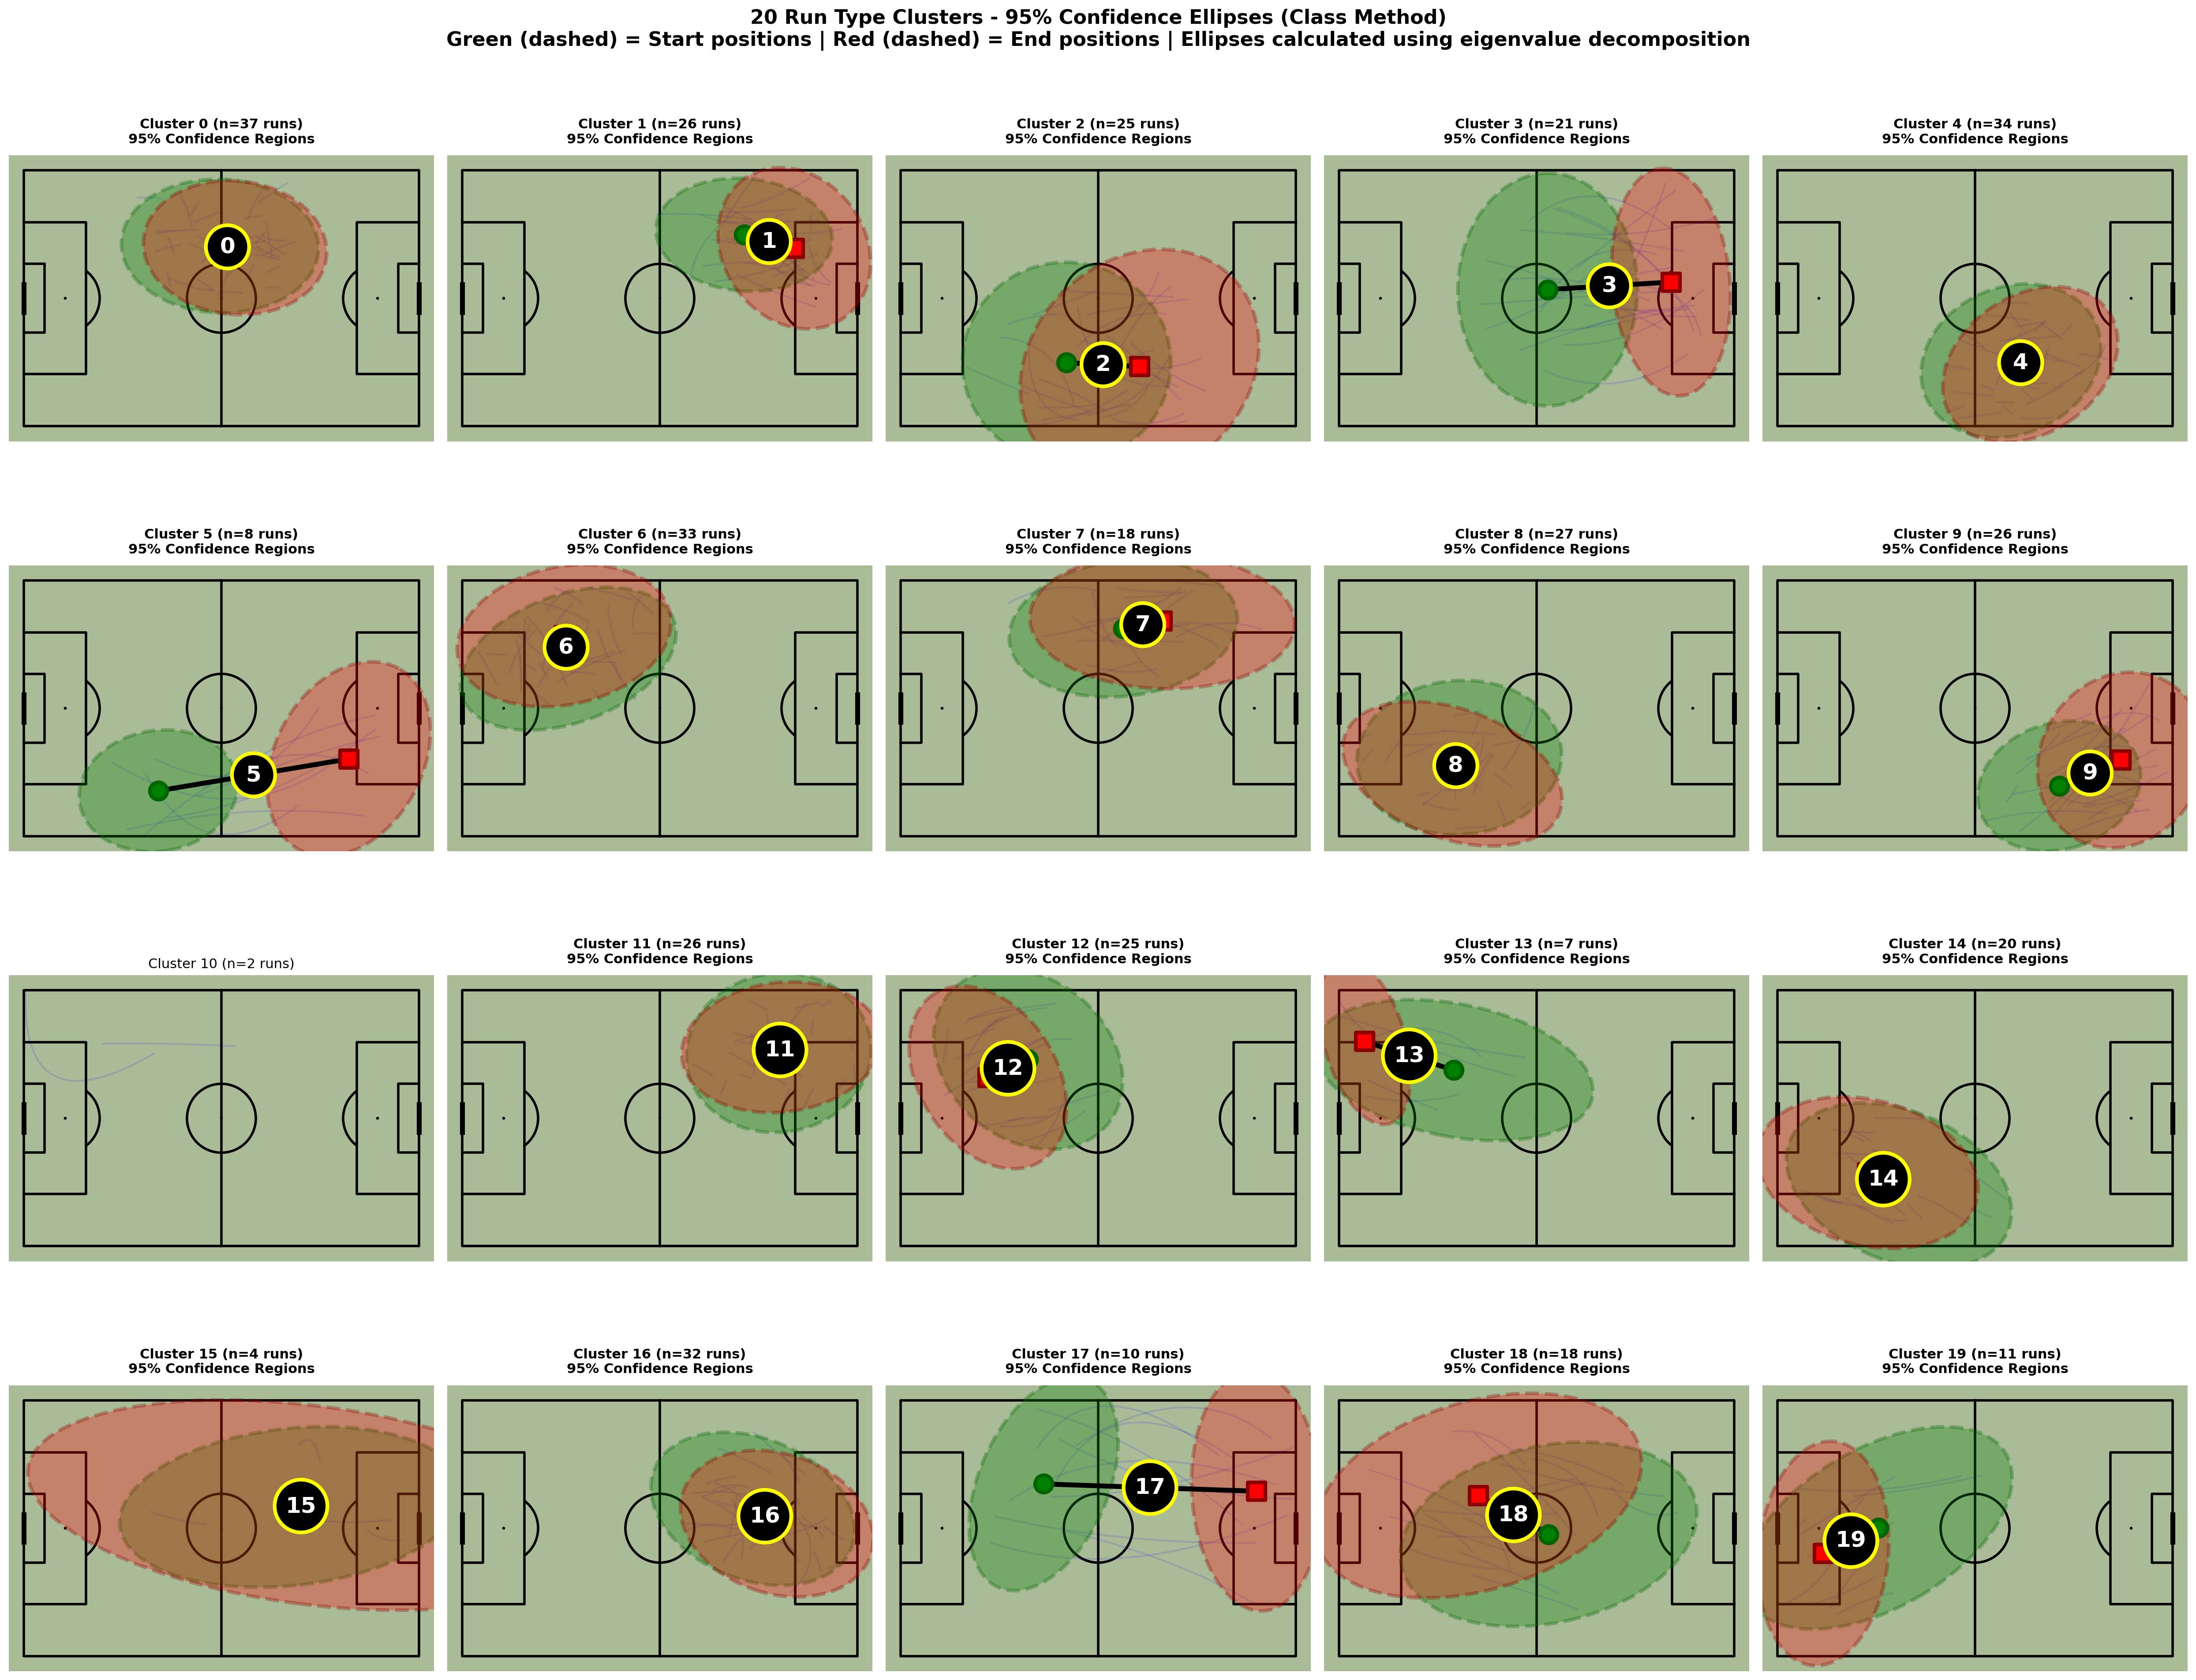

✓ Saved: run_clusters_CONFIDENCE_CLASS_METHOD.png


In [ ]:
# =============================================================================
# CONFIDENCE REGION PLOTS
# =============================================================================

from scipy.stats import chi2

def confidence_region(track, level=0.95):
    """
    Calculate confidence ellipse parameters (from class).

    Parameters:
    - track: array of [x, y] coordinates
    - level: confidence level (default 0.95 = 95%)

    Returns: dict with ellipse parameters
    """
    cov = np.cov(track.T)
    vals, vecs = np.linalg.eig(cov)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    scale = np.sqrt(chi2.ppf(level, df=2))

    return {
        "xy": track.mean(axis=0),
        "width": np.sqrt(vals[0]) * scale,
        "height": np.sqrt(vals[1]) * scale,
        "angle": angle,
    }


# -----------------------------------------------------------------------------
# METHOD 1: START AND END CONFIDENCE ELLIPSES
# -----------------------------------------------------------------------------

def plot_clusters_confidence_regions_class(runs, labels, cluster_stats, n_clusters,
                                           pitch_length=105, pitch_width=68,
                                           confidence_level=0.95):
    """
    Plot clusters with confidence regions using professor's method.
    Separate ellipses for start and end positions.
    """
    fig, axes = plt.subplots(4, 5, figsize=(25, 20))
    axes = axes.flatten()

    for cluster_id in range(n_clusters):
        ax = axes[cluster_id]

        pitch = Pitch(pitch_type='custom', pitch_length=pitch_length,
                     pitch_width=pitch_width, line_color='black',
                     pitch_color='#aabb97', linewidth=2)
        pitch.draw(ax=ax)

        cluster_runs = [runs[i] for i in range(len(runs)) if labels[i] == cluster_id]

        # Plot individual runs
        for run in cluster_runs:
            period_array = np.full(len(run['x']), run['period'])
            x_norm, y_norm = normalize_positions(
                run['x'], run['y'], period_array,
                pitch_length, pitch_width
            )

            bezier_x, bezier_y = apply_bezier_curve(x_norm, y_norm, num_points=100)

            pitch.plot(bezier_x, bezier_y, ax=ax, color='blue',
                      alpha=0.12, lw=1.5, zorder=1)

        # Calculate and plot confidence regions
        if len(cluster_runs) >= 3:  # Need at least 3 points for covariance
            # Collect start and end positions
            start_positions = []
            end_positions = []

            for run in cluster_runs:
                period_array = np.full(len(run['x']), run['period'])
                x_norm, y_norm = normalize_positions(
                    run['x'], run['y'], period_array,
                    pitch_length, pitch_width
                )
                start_positions.append([x_norm[0], y_norm[0]])
                end_positions.append([x_norm[-1], y_norm[-1]])

            start_positions = np.array(start_positions)
            end_positions = np.array(end_positions)

            # Calculate confidence regions using class method
            start_conf = confidence_region(start_positions, level=confidence_level)
            end_conf = confidence_region(end_positions, level=confidence_level)

            # Plot start position confidence ellipse (green)
            ellipse_start = Ellipse(
                xy=start_conf['xy'],
                width=start_conf['width'] * 2,  # diameter
                height=start_conf['height'] * 2,
                angle=start_conf['angle'],
                facecolor='green',
                alpha=0.3,
                edgecolor='darkgreen',
                linewidth=3,
                linestyle='--',
                zorder=2
            )
            ax.add_patch(ellipse_start)

            # Plot end position confidence ellipse (red)
            ellipse_end = Ellipse(
                xy=end_conf['xy'],
                width=end_conf['width'] * 2,
                height=end_conf['height'] * 2,
                angle=end_conf['angle'],
                facecolor='red',
                alpha=0.3,
                edgecolor='darkred',
                linewidth=3,
                linestyle='--',
                zorder=2
            )
            ax.add_patch(ellipse_end)

            # Mean trajectory
            pitch.plot(
                [start_conf['xy'][0], end_conf['xy'][0]],
                [start_conf['xy'][1], end_conf['xy'][1]],
                ax=ax, color='black', lw=4, zorder=3
            )

            # Cluster number
            mid_x = (start_conf['xy'][0] + end_conf['xy'][0]) / 2
            mid_y = (start_conf['xy'][1] + end_conf['xy'][1]) / 2

            ax.text(mid_x, mid_y, str(cluster_id),
                   fontsize=18, fontweight='bold', color='white',
                   ha='center', va='center',
                   bbox=dict(boxstyle='circle,pad=0.5',
                            facecolor='black',
                            edgecolor='yellow',
                            linewidth=3),
                   zorder=5)

            # Mean markers
            pitch.scatter(start_conf['xy'][0], start_conf['xy'][1],
                         ax=ax, color='green', s=200, zorder=4,
                         edgecolors='darkgreen', linewidth=3)

            pitch.scatter(end_conf['xy'][0], end_conf['xy'][1],
                         ax=ax, color='red', s=200, zorder=4, marker='s',
                         edgecolors='darkred', linewidth=3)

            ax.set_title(f'Cluster {cluster_id} (n={len(cluster_runs)} runs)\n' +
                       f'{int(confidence_level*100)}% Confidence Regions',
                       fontsize=11, fontweight='bold', pad=10)
        else:
            ax.set_title(f'Cluster {cluster_id} (n={len(cluster_runs)} runs)',
                        fontsize=11)

    plt.suptitle(f'20 Run Type Clusters - {int(confidence_level*100)}% Confidence Ellipses (Class Method)\n' +
                 f'Green (dashed) = Start positions | Red (dashed) = End positions | ' +
                 f'Ellipses calculated using eigenvalue decomposition',
                 fontsize=16, fontweight='bold', y=0.998)
    plt.tight_layout()
    plt.savefig('run_clusters_CONFIDENCE_CLASS_METHOD.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: run_clusters_CONFIDENCE_CLASS_METHOD.png")



plot_clusters_confidence_regions_class(runs, labels, cluster_stats, N_CLUSTERS,
                                       PITCH_LENGTH, PITCH_WIDTH,
                                       confidence_level=0.95)


